<a href="https://colab.research.google.com/github/tanishq2905/ML-project/blob/main/ML_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


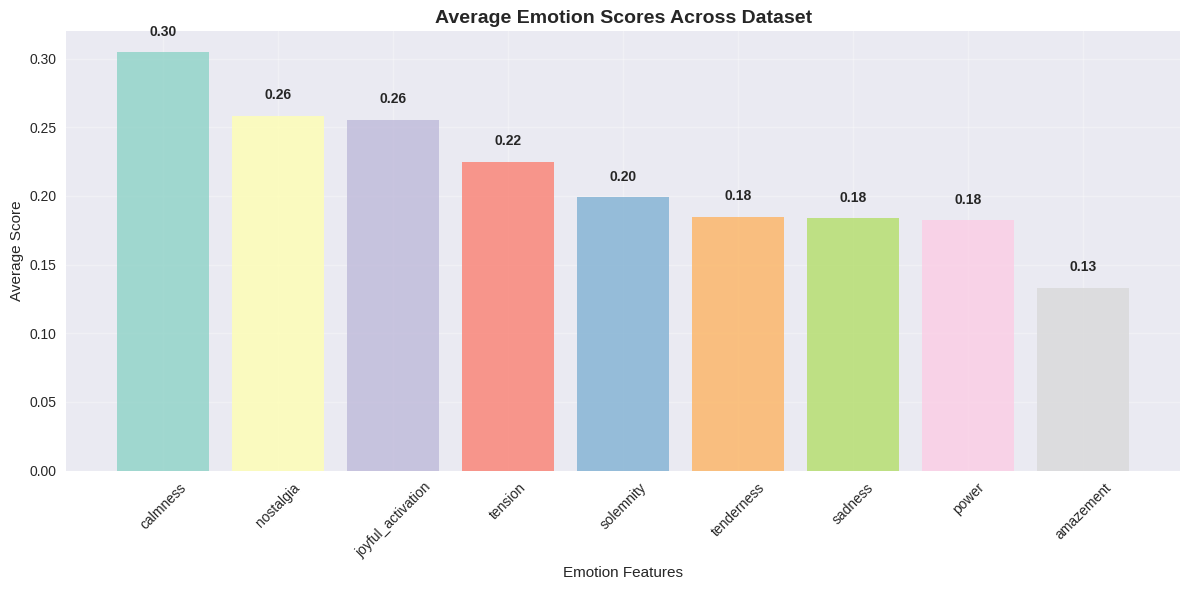

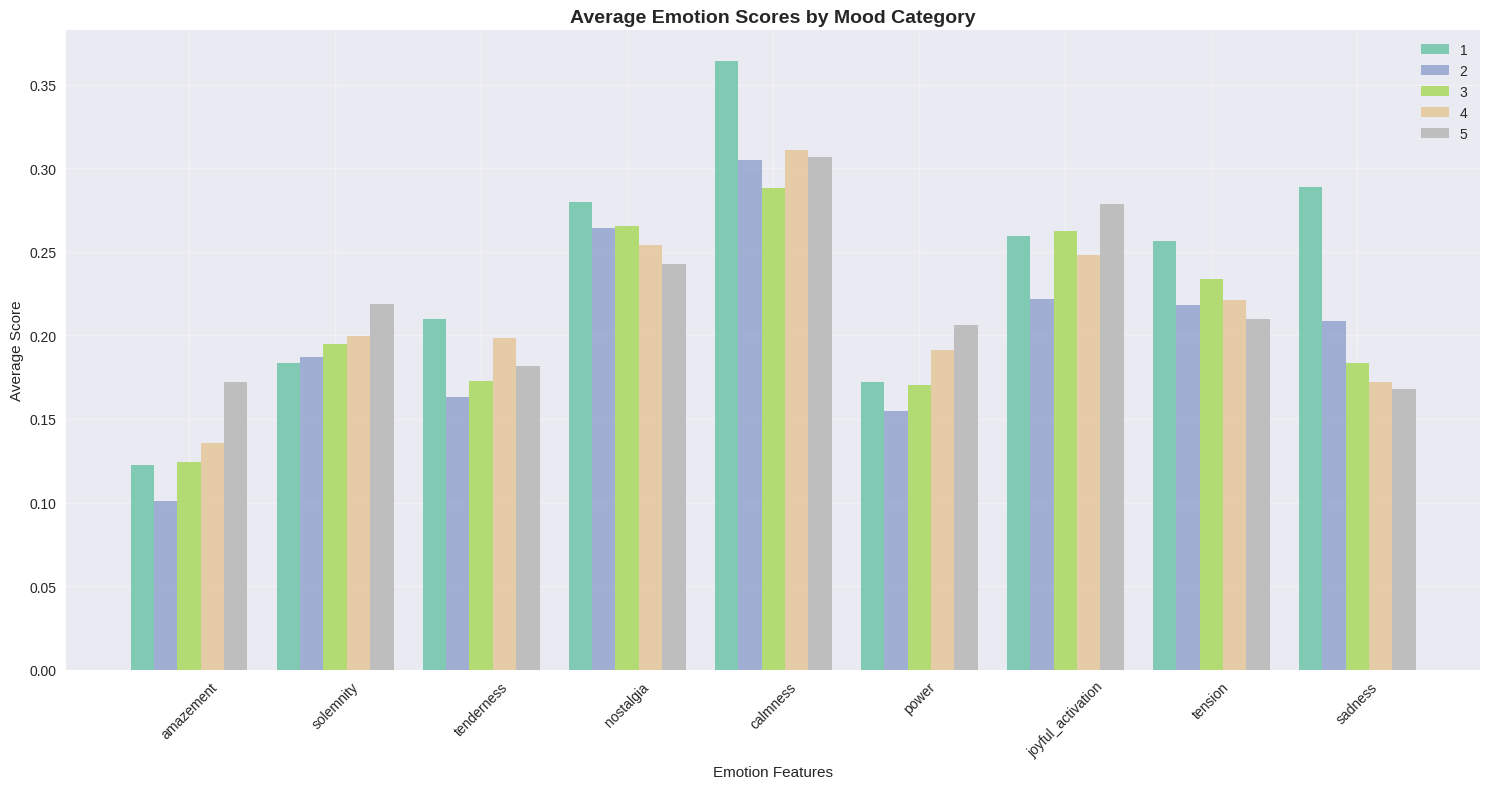

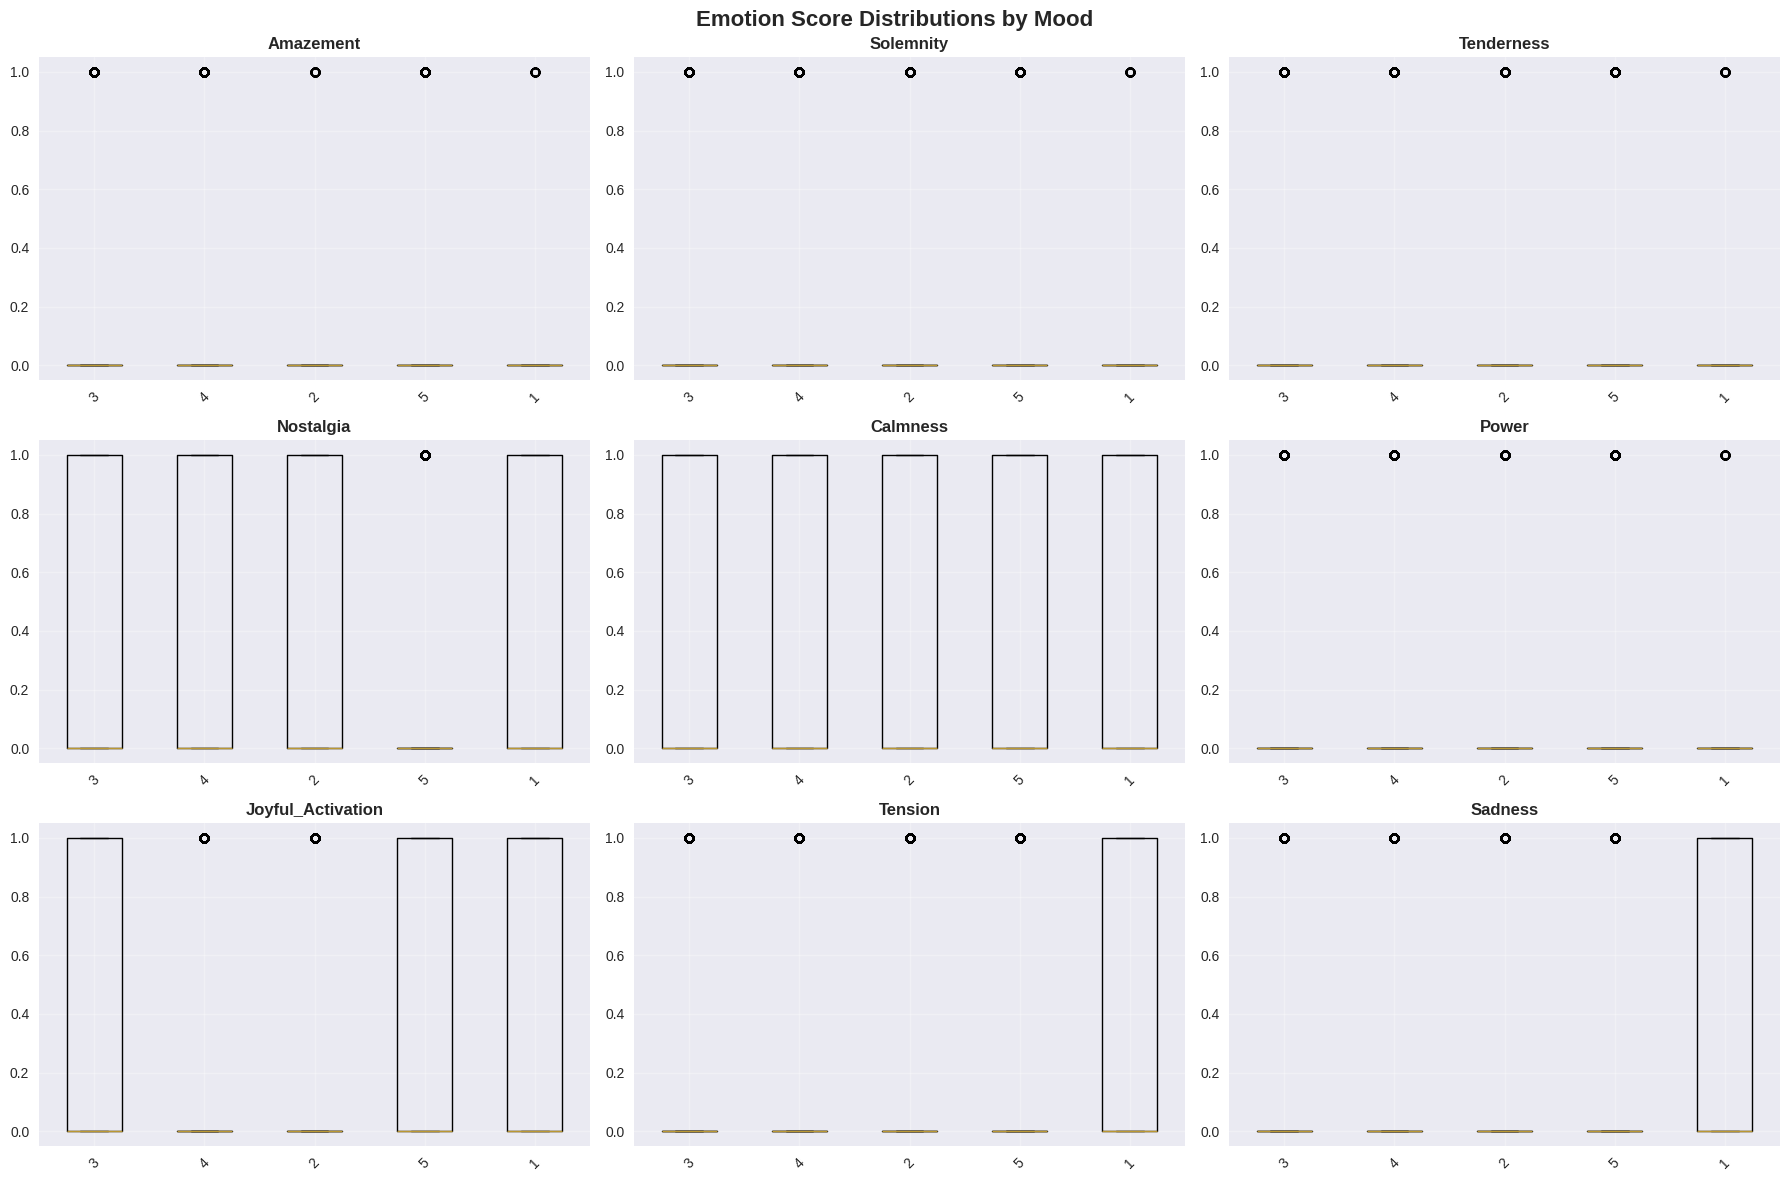

Model Performance Results:
                           Train Accuracy  Test Accuracy  Precision  Recall  \
Logistic Regression                0.3929         0.3769     0.2582  0.3769   
PCA + Logistic Regression          0.3868         0.3888     0.2830  0.3888   
Neural Network                     0.4058         0.3930     0.3287  0.3930   
Random Forest                      0.4088         0.3876     0.3221  0.3876   

                           F1-Score  
Logistic Regression          0.2675  
PCA + Logistic Regression    0.2351  
Neural Network               0.3178  
Random Forest                0.3203  


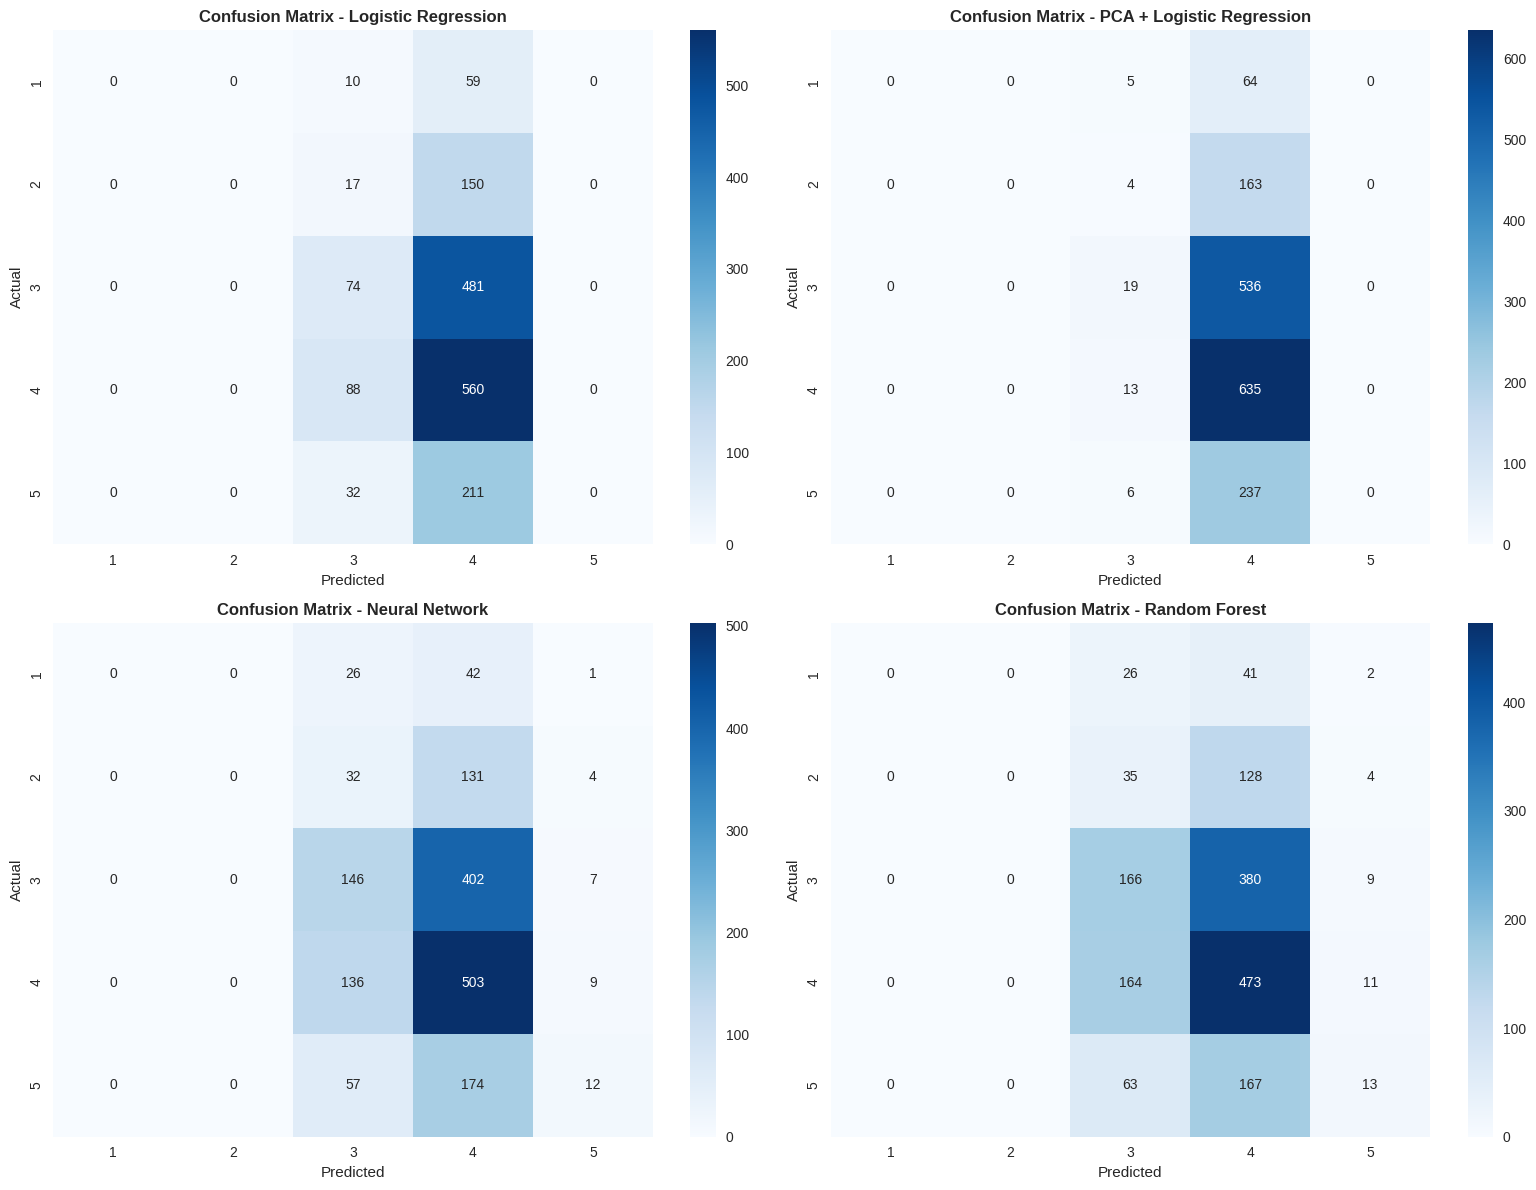

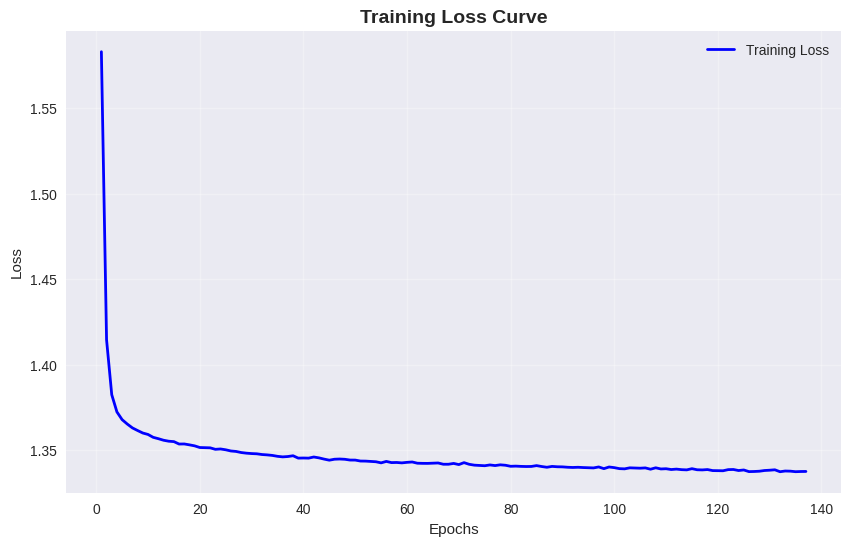

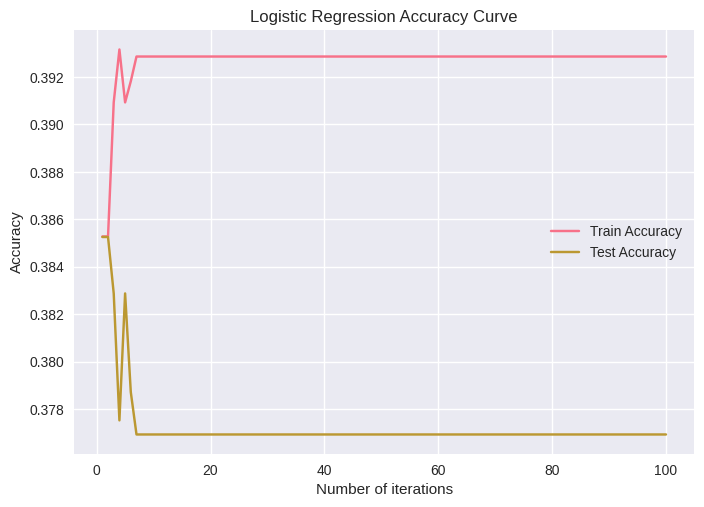


Best Model: Neural Network (Accuracy: 0.3930)

Classification Report - Neural Network:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        69
           2       0.00      0.00      0.00       167
           3       0.37      0.26      0.31       555
           4       0.40      0.78      0.53       648
           5       0.36      0.05      0.09       243

    accuracy                           0.39      1682
   macro avg       0.23      0.22      0.18      1682
weighted avg       0.33      0.39      0.32      1682



In [ ]:
# Music Emotion Detection ML Pipeline with Emotion Bar Graphs and Confusion Matrix
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                           precision_recall_fscore_support)
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Step 2: Load dataset
data = pd.read_csv('data.csv', header=0)
data.columns = data.columns.str.strip()

# Step 3: Data preprocessing
emotion_features = ['amazement', 'solemnity', 'tenderness', 'nostalgia', 'calmness',
                    'power', 'joyful_activation', 'tension', 'sadness']
try:
    X = data[emotion_features]
    y = data['mood']
except KeyError as e:
    print("KeyError: missing columns. Available columns:", data.columns.tolist())
    raise e

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

# VISUALIZATION 1: EMOTION BAR GRAPHS

# 1.1 Average Emotion Scores
plt.figure(figsize=(12, 6))
emotion_means = X.mean().sort_values(ascending=False)
bars = plt.bar(range(len(emotion_means)), emotion_means.values,
               color=plt.cm.Set3(range(len(emotion_means))), alpha=0.8)
plt.title('Average Emotion Scores Across Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Emotion Features')
plt.ylabel('Average Score')
plt.xticks(range(len(emotion_means)), emotion_means.index, rotation=45)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, emotion_means.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.2f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# 1.2 Emotion Scores by Mood Category
mood_emotion_means = data.groupby('mood')[emotion_features].mean()

plt.figure(figsize=(15, 8))
x = np.arange(len(emotion_features))
width = 0.8 / len(mood_emotion_means.index)
colors = plt.cm.Set2(np.linspace(0, 1, len(mood_emotion_means.index)))

for i, (mood, color) in enumerate(zip(mood_emotion_means.index, colors)):
    plt.bar(x + i * width, mood_emotion_means.loc[mood], width,
            label=mood, alpha=0.8, color=color)

plt.title('Average Emotion Scores by Mood Category', fontsize=14, fontweight='bold')
plt.xlabel('Emotion Features')
plt.ylabel('Average Score')
plt.xticks(x + width * (len(mood_emotion_means.index) - 1) / 2, emotion_features, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 1.3 Emotion Distribution Comparison
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.ravel()

for i, emotion in enumerate(emotion_features):
    mood_data = []
    mood_labels = []

    for mood in y.unique():
        mood_scores = X.loc[y == mood, emotion]
        mood_data.append(mood_scores.values)
        mood_labels.append(mood)

    axes[i].boxplot(mood_data, labels=mood_labels)
    axes[i].set_title(f'{emotion.title()}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Emotion Score Distributions by Mood', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# MACHINE LEARNING PIPELINE (SILENT TRAINING)

# Define pipelines
pipeline_direct = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500, random_state=42))
])

pipeline_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5)),
    ('clf', LogisticRegression(max_iter=500, random_state=42))
])

pipeline_nn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(max_iter=500, random_state=42))
])

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipelines = {
    'Logistic Regression': pipeline_direct,
    'PCA + Logistic Regression': pipeline_pca,
    'Neural Network': pipeline_nn,
    'Random Forest': pipeline_rf
}

# Train and evaluate models (silently)
results = {}
predictions = {}

for name, pipeline in pipelines.items():
    # Train model
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    predictions[name] = y_pred_test

    # Calculate metrics
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_test, average='weighted')

    results[name] = {
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Display results table
results_df = pd.DataFrame(results).T
print("Model Performance Results:")
print(results_df.round(4))

# VISUALIZATION 2: CONFUSION MATRICES

# Confusion Matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=np.unique(y), yticklabels=np.unique(y))
    axes[i].set_title(f'Confusion Matrix - {name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Neural Network Loss Curve (if available)
nn_pipeline = pipelines['Neural Network']
if hasattr(nn_pipeline.named_steps['clf'], 'loss_curve_'):
    loss_values = nn_pipeline.named_steps['clf'].loss_curve_
    epochs = range(1, len(loss_values) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, loss_values, 'b-', linewidth=2, label='Training Loss')
    plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Accuracy curve
from sklearn.linear_model import LogisticRegression
import numpy as np

max_iters = 100
train_acc = []
test_acc = []

clf = LogisticRegression(max_iter=1, warm_start=True)

for i in range(max_iters):
    clf.max_iter = i+1
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

plt.plot(range(1, max_iters+1), train_acc, label='Train Accuracy')
plt.plot(range(1, max_iters+1), test_acc, label='Test Accuracy')
plt.xlabel('Number of iterations')
plt.ylabel('Accuracy')
plt.title('Logistic Regression Accuracy Curve')
plt.legend()
plt.show()


# Final Results Summary
ranking = results_df.sort_values('Test Accuracy', ascending=False)
print(f"\nBest Model: {ranking.index[0]} (Accuracy: {ranking.iloc[0]['Test Accuracy']:.4f})")

# Classification report for best model
best_model_name = ranking.index[0]
best_predictions = predictions[best_model_name]
print(f"\nClassification Report - {best_model_name}:")
print(classification_report(y_test, best_predictions))




STREAMLIT

In [ ]:
# Cell 1: Install packages (if already installed, this is safe to repeat)
!pip install -q streamlit scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.5 MB/s eta 0:00:00


In [ ]:
# Cell 2: Download tunnel binary
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [ ]:
# Cell 3: app.py
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
st.set_page_config(page_title="Music Emotion Classifier", page_icon="🎵", layout="centered")
st.title("🎵 Music Emotion Classifier")
st.caption("Try music emotion classification with sliders or upload your own dataset (see sidebar).")
EMOTION_FEATURES = ['amazement','solemnity','tenderness','nostalgia','calmness',
                    'power','joyful_activation','tension','sadness']

st.sidebar.header("Upload or Use Sample Data")
upl = st.sidebar.file_uploader("Upload CSV", type="csv")
if upl is not None:
    data = pd.read_csv(upl)
    data = data.dropna()
    if all(f in data.columns for f in EMOTION_FEATURES + ["mood"]):
        sample_df = data
        st.sidebar.success(f"Custom data loaded: {len(sample_df)} rows.")
    else:
        st.sidebar.warning("Required columns: " + ", ".join(EMOTION_FEATURES + ["mood"]))
        sample_df = None
else:
    sample_df = pd.DataFrame(
        [
            [0.2,0.7,0.4,0.6,0.8,0.3,0.1,0.2,0.8,"sad"],
            [0.8,0.3,0.6,0.4,0.2,0.9,0.8,0.7,0.1,"happy"],
            [0.5,0.6,0.8,0.7,0.9,0.2,0.3,0.1,0.4,"calm"],
            [0.1,0.9,0.2,0.8,0.5,0.1,0.2,0.9,0.7,"tense"],
            [0.7,0.2,0.5,0.3,0.4,0.8,0.9,0.3,0.2,"energetic"],
            [0.3,0.8,0.7,0.9,0.6,0.2,0.1,0.4,0.6,"melancholic"]
        ], columns=EMOTION_FEATURES + ["mood"]
    )
    st.sidebar.info("No data uploaded. Using mini sample dataset.")
st.subheader("Input Features")
defaults = sample_df[EMOTION_FEATURES].mean().values if sample_df is not None else [0.5]*9
ranges = [(0.0, 1.0)]*len(EMOTION_FEATURES)
cols = st.columns(3)
vals = []
for i, (c, fname, d, (lo, hi)) in enumerate(zip(cols*3, EMOTION_FEATURES, defaults, ranges)):
    with c:
        vals.append(st.slider(fname.replace("_", " ").title(), float(lo), float(hi), float(d), 0.01, key=fname))
X_input = np.array(vals, dtype=float).reshape(1, -1)

st.subheader("Classifier and Prediction")
@st.cache_resource
def train_music_pipeline(df):
    enc = LabelEncoder()
    y_enc = enc.fit_transform(df["mood"])
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=40, random_state=42))
    ])
    pipe.fit(df[EMOTION_FEATURES], y_enc)
    return pipe, enc
pipe, mood_encoder = train_music_pipeline(sample_df)
mood_mode = st.radio("Show", ["Predicted Mood", "All Mood Probabilities"], horizontal=True)
if st.button("Predict"):
    pred = pipe.predict(X_input)[0]
    pred_label = mood_encoder.inverse_transform([pred])[0]
    st.success(f"Predicted mood: **{pred_label}**")
    if mood_mode == "All Mood Probabilities":
        proba = pipe.predict_proba(X_input)[0]
        prob_df = pd.DataFrame({"mood": mood_encoder.classes_, "probability": proba})
        st.dataframe(prob_df.sort_values("probability", ascending=False).reset_index(drop=True))
st.caption("Tip: Use sliders above and compare different moods. Upload your own dataset for real results.")
if st.checkbox("Show data table"):
    st.dataframe(sample_df.head(20))


Writing app.py


In [ ]:
# Cell 4: Start Streamlit (headless, background)
import subprocess
import time
!pkill -f streamlit || true
streamlit_proc = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
)
time.sleep(5)

^C


In [ ]:
# Cell 5: Launch cloudflared tunnel (get public URL)
import re
cloudflared_proc = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8501", "--no-autoupdate"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
)
public_url = None
pattern = re.compile(r"https://[0-9a-z-]+\.trycloudflare\.com")
for _ in range(60):
    line = cloudflared_proc.stdout.readline()
    if "trycloudflare.com" in line:
        match = pattern.search(line)
        if match:
            public_url = match.group(0)
            break
    time.sleep(0.1)
if public_url:
    print("🌐 Your Music Emotion App is live at:", public_url)
else:
    print("Tunnel URL not found.")

🌐 Your Music Emotion App is live at: https://includes-confirmed-close-bears.trycloudflare.com
